<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Caracterización de señales de electrohisterografía y su relación con la finalización del parto
##### ¿Existen diferencias temporales y espectrales en la actividad uterina (EHG) que permitan distinguir entre registros de embarazos que finalizaron en parto pretérmino y a término?

#### Milena Waichman Scigliano


## Introduccíon

La electrohisterografía (EHG) permite registrar de forma no invasiva la actividad eléctrica del músculo uterino y constituye una herramienta de interés para el estudio de la dinámica del trabajo de parto. Diversos estudios han mostrado que las características de estas señales se encuentran relacionadas con la eficacia de las contracciones y, en consecuencia, con el desenlace del parto.

Para este trabajo se utilizó la base de datos TPEHG DB (Term-Preterm EHG Database), disponible públicamente en PhysioNet [1]. La base de datos contiene 262 registros de EHG correspondientes a embarazos que finalizaron en parto a término (≥37 semanas) y pretérmino (<37 semanas), obtenidos entre la semana 22 y la 32 de gestación.

Cada registro está compuesto por tres señales bipolares de superficie obtenidas mediante electrodos colocados sobre el abdomen de la paciente, con una duración aproximada de treinta minutos y una frecuencia de muestreo de 20 Hz. Para este trabajo se utilizó únicamente el canal S1, correspondiente a la señal medida entre los dos electrodos superiores, por considerarse el más representativo para el análisis de la actividad uterina en el contexto de este trabajo.
<div style="text-align: center;">
  <img src="electrodos.png" width="450"/>
  <p style="text-align: center;"><strong>Figura 1:</strong> Colocación de electrodos para registro de EHG. Fuente: Jager, F. (2023) [3]</p>
</div>

El objetivo del trabajo es implementar un análisis de señales EHG, incluyendo filtrado, normalización, segmentación y extracción de features, y aplicarlo a registros de pacientes con distintos desenlaces de parto, analizando las características obtenidas desde una perspectiva temporal, espectral y de complejidad de la señal.



## Preprocesamiento

Previo a la digitalización, las señales fueron filtradas analógicamente mediante un filtro anti-aliasing Butterworth pasabajos con frecuencia de corte $f_c = 5 Hz$, con el objetivo de eliminar componentes de alta frecuencia que podrían causar aliasing durante el muestreo. De acuerdo al teorema de Nyquist, la frecuencia de muestreo utilizada de $f_s = 20 Hz$ garantiza la correcta representación de todas las componentes espectrales por debajo de $f_N = 10 Hz$, cubriendo el rango de interés fisiológico de la señal EHG.

Para la lectura de los registros se utilizó la librería WFDB (Waveform Database) de Python, que provee herramientas para la lectura y procesamiento de señales fisiológicas en formato PhysioNet. De los tres canales disponibles en cada registro, se seleccionó el canal *S1*, correspondiente a la señal bipolar entre los dos electrodos superiores, por considerarse el más representativo para el análisis de la actividad uterina en el contexto de este trabajo. Esta elección es consistente con la utilizada en estudios previos sobre la misma base de datos [3].

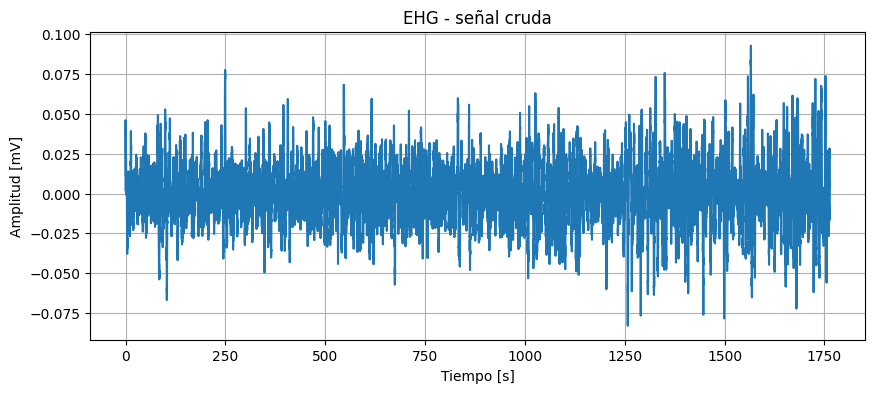

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import wfdb as wfdb
from scipy import signal
import scipy.io as sio

from pytc2.sistemas_lineales import plot_plantilla

def cargar_senal(path):
    archivo = wfdb.rdrecord(path)
    
    senal = archivo.p_signal
    fs = archivo.fs
    
    ehg = senal[:, 1]
    t = np.arange(len(ehg)) / fs
    
    return ehg, t, fs

def plot_senal_cruda(t, ehg):
    plt.figure(figsize=(10,4))
    plt.plot(t, ehg)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud [mV]')
    plt.title('EHG - señal cruda')
    plt.grid()

ehg, t, fs = cargar_senal('data/tpehgdb/tpehg639')
plot_senal_cruda(t = t, ehg = ehg)

### Análisis espectral

Previo al filtrado se realizó un análisis espectral de la señal con el objetivo de caracterizar su contenido frecuencial e identificar las bandas de interés fisiológico para el diseño del filtro.

Para la estimación de la densidad espectral de potencia (PSD) se utilizó el método de Welch, que divide la señal en segmentos solapados, aplica una función ventana a cada uno y promedia los periodogramas resultantes. Este promediado reduce la varianza de la estimación a costa de una menor resolución frecuencial, lo cual es especialmente útil en señales biomédicas no estacionarias como el EHG. La ventana utilizada fue de tipo *Flattop*, adecuada cuando se busca precisión en la estimación de la amplitud espectral.

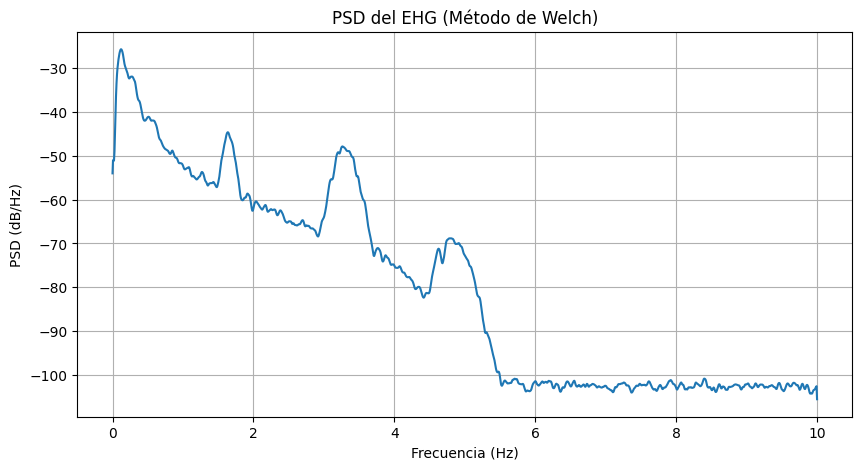

In [100]:
def calcular_psd(ehg, fs, cant_promedio=25, win="flattop"):
    N = len(ehg)
    nperseg = N // cant_promedio
    nfft = 2 * nperseg
    
    f_welch, psd = signal.welch(ehg, fs=fs, window=win, nperseg=nperseg, nfft=nfft)
    psd_db = 10 * np.log10(psd)
    
    return f_welch, psd, psd_db  

def plot_psd(f, psd_db):
    plt.figure(figsize=(10,5))
    plt.plot(f, psd_db)
    plt.title('PSD del EHG (Método de Welch)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('PSD (dB/Hz)')
    plt.grid(True)
    
f_psd, psd, psd_db = calcular_psd(ehg, fs)
plot_psd(f = f_psd, psd_db = psd_db)


Como se observa en el gráfico de PSD, la mayor parte de la energía de la señal se concentra en la banda de aproximadamente $0.3-3,5 Hz$, con una caída significativa fuera de este rango. Esto justifica el diseño de un filtro pasabanda con frecuencias de corte en ese rango, con el objetivo de aislar las componentes fisiológicas de interés y atenuar el ruido de baja frecuencia (deriva de línea de base) y de alta frecuencia presentes en el registro.

### Filtrado

Para el filtrado de la señal se diseñó un filtro pasabanda digital de tipo Butterworth utilizando la función *IIRdesign* de SciPy, que permite especificar directamente los parámetros de la plantilla de diseño en frecuencia y atenuación.

Se eligió la aproximación Butterworth por su respuesta en magnitud maximamente plana en la banda de paso, lo que garantiza que las componentes frecuenciales de interés fisiológico sean preservadas sin ondulaciones ni distorsiones de amplitud.

A partir del análisis espectral previo, se determinaron los siguientes parámetros de diseño:
$$\omega_p=[0.3,2.5] \text{ Hz} \quad \text{(banda de paso)}$$
$$\omega_s = [0.1, 3.5] \text{ Hz} \quad \text{(banda de stop)}$$
$$\alpha_p = 3 \text{ dB} \quad \text{(máxima atenuación en banda de paso)}$$
$$\alpha_s = 40 \text{ dB} \quad \text{(mínima atenuación en banda de stop)}$$

La atenuación de banda de paso $\alpha_p=3 dB$ corresponde a una caída de amplitud de $1/\sqrt{2}$ respecto al valor máximo, criterio estándar para la definición de frecuencia de corte. La atenuación de stop $\alpha_s = 40 dB$ garantiza una supresión suficiente del ruido de baja frecuencia (deriva de línea de base) y de alta frecuencia presentes en el registro.

El filtro fue implementado de forma bidireccional mediante *sosfiltfilt*, aplicando el filtro en ambas direcciones temporales para obtener fase nula. Esto es fundamental en el análisis de señales EHG ya que evita el desplazamiento temporal de las contracciones, preservando la morfología y la ubicación temporal de los eventos de actividad uterina.

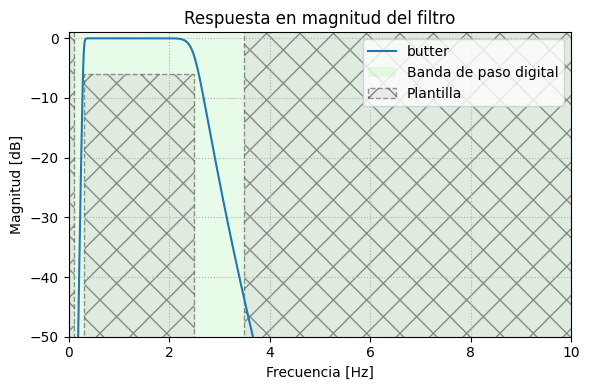

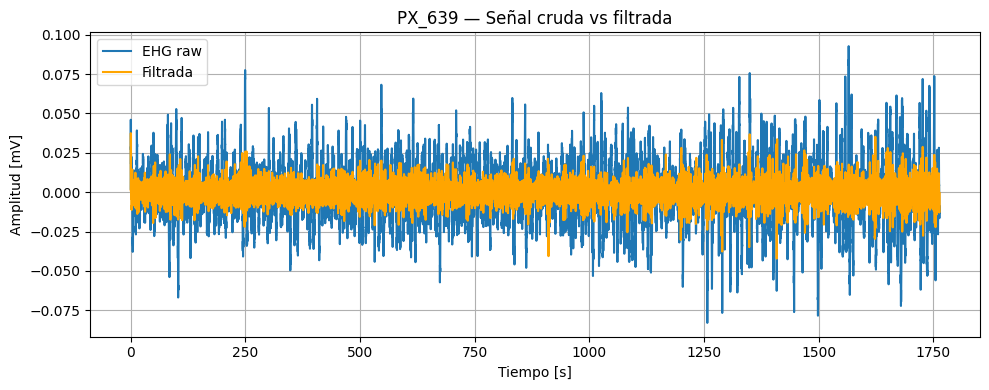

In [112]:
wp = (0.3, 2.5)
ws = (0.1, 3.5)
alpha_p = 3
alpha_s = 40

def filtrar_senal(ehg, fs, wp=(0.3, 2.5), ws=(0.1, 3.5), alpha_p=3, alpha_s=40, f_aprox = 'butter'):
    
    mi_sos_butter = signal.iirdesign(wp = wp, ws = ws, gpass = alpha_p, gstop = alpha_s, analog = False, ftype = f_aprox, output ='sos', fs=fs)
    
    ehg_filt = signal.sosfiltfilt(mi_sos_butter, ehg)
   
    w, h= signal.freqz_sos(mi_sos_butter, worN = np.logspace(-2, 1.9, 1000), fs = fs) #calcula rta en frq del filtro, devuelve w y vector de salida (h es numero complejo)
    fase = np.unwrap(np.angle(h)) #unwrap hace grafico continuo

    w_rad = w / (fs / 2) * np.pi
    retardo = -np.diff(fase) / np.diff(w_rad)
    
    return mi_sos_butter, ehg_filt, w, h, fase, retardo

def plot_senal_filtrada(t, ehg, ehg_filt, nombre=''):
    plt.figure(figsize=(10,4))
    plt.plot(t, ehg, label='EHG raw')
    plt.plot(t, ehg_filt, label='Filtrada', color='orange')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud [mV]')
    plt.title(f'{nombre} — Señal cruda vs filtrada')
    plt.legend()
    plt.grid()
    plt.tight_layout()

def plot_respuesta_filtro(w, h, wp, ws, alpha_p, alpha_s, fs, f_aprox='butter'):
    
    plt.figure(figsize=(6,4))
    
    plt.plot(w, 20*np.log10(np.maximum(abs(h), 1e-10)), label=f_aprox)
    
    plot_plantilla(filter_type='bandpass', fpass=wp, ripple=alpha_p*2, fstop=ws, attenuation=alpha_s*2,fs=fs)
    
    plt.title('Respuesta en magnitud del filtro')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Magnitud [dB]')
    
    plt.xlim([0, 10])
    plt.ylim([-50, 1])
    
    plt.grid(True, which='both', ls=':')
    plt.legend()
    plt.tight_layout()
    

mi_sos_butter, ehg_filt, w, h, fase, retardo = filtrar_senal(ehg, fs)
plot_respuesta_filtro(w = w, h = h, wp = wp, ws = ws, alpha_p = alpha_p, alpha_s = alpha_s, fs = fs)
plot_senal_filtrada(t = t, ehg = ehg, ehg_filt = ehg_filt, nombre='PX_639')

Como se observa, la respuesta en magnitud del filtro diseñado cumple con la plantilla especificada, con atenuación menor a 3 dB en la banda de paso y mayor a 40 dB en las bandas de stop.

### Normalización

Para poder comparar las señales de distintas pacientes, cada señal fue normalizada mediante z-score, restando la media y dividiendo por el desvío estándar de la señal completa filtrada:
$$x_{norm}=\frac{x−\mu}{\sigma}$$
Este paso es necesario porque las señales EHG pueden presentar diferencias de amplitud entre pacientes que no tienen origen fisiológico, sino instrumental: variaciones en la impedancia de contacto de los electrodos, diferente grosor del tejido subcutáneo o diferencias en la ganancia del sistema de adquisición. Normalizar elimina esa variabilidad y garantiza que las features extraídas en etapas posteriores sean comparables entre pacientes.

In [102]:
def normalizar_senal(x):
    media = np.mean(x)
    desvio = np.std(x)
    return (x - media) / desvio

### Segmentación

La señal normalizada fue segmentada en ventanas rectangulares de 120 segundos con un solapamiento del 50%. Estos valores fueron adoptados siguiendo la metodología propuesta en la literatura de análisis de señales EHG $[3]$, donde ventanas de esta duración permiten capturar la dinámica local de la actividad uterina y obtener estimaciones espectrales estables, mientras que el solapamiento del 50% maximiza la cantidad de ventanas disponibles manteniendo un costo computacional razonable.


In [103]:
def segmentar_senal(x, fs, window_length=120, overlap=0.5):
    
    L = int(window_length * fs)
    step = int(L * (1 - overlap))
    
    ventanas = []
    inicios = []
    
    for start in range(0, len(x) - L + 1, step):
        ventanas.append(x[start:start + L])
        inicios.append(start)
    
    # Tiempo del centro de cada ventana
    tiempo = np.array([s + L/2 for s in inicios]) / fs
    
    return ventanas, tiempo

## Extracción de features

Con el objetivo de caracterizar la actividad eléctrica uterina y distinguir entre distintos patrones fisiológicos, se extrajeron features de cada ventana en tres dominios complementarios: temporal, espectral y no lineal. Los parámetros temporales cuantifican la intensidad de la actividad contráctil, los espectrales capturan los cambios en el contenido frecuencial de la señal asociados a la proximidad del parto, y los no lineales evalúan la complejidad y regularidad de la dinámica uterina. Este enfoque multidominio está respaldado por la literatura, que indica que ninguna feature individual es suficiente por sí sola para caracterizar completamente la señal EHG $[3]$.

### RMS

La energía y el valor cuadrático medio (RMS) son parámetros temporales que cuantifican la magnitud de la señal EHG en cada ventana. La energía se define como la suma de los cuadrados de las muestras de amplitud:
$$E = \sum_{n=0}^{N-1} x[n]^2$$
y el RMS como la raíz cuadrada de la media de esos cuadrados:
$$RMS = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1} x[n]^2} = \sqrt{\frac{E}{N}}$$
En este trabajo se utiliza el RMS como métrica de amplitud por ser independiente de la longitud de la ventana, lo que facilita la comparación entre segmentos.

Fisiológicamente, durante una contracción uterina el reclutamiento de fibras miometriales aumenta, lo que se traduce en mayor amplitud de la señal EHG y por ende en valores más elevados de la métrica. Es por lo tanto un indicador directo de la intensidad de la actividad contráctil uterina.

In [104]:
def calcular_energia_rms(ventanas):
    energias = []
    rms = []
    
    for v in ventanas:
        energias.append(np.sum(v**2))
        rms.append(np.sqrt(np.mean(v**2)))
    
    return np.array(energias), np.array(rms)

def plot_energia(t_vent, energia):
    plt.figure(figsize=(10,4))
    plt.plot(t_vent, energia)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Energía")
    plt.title("Energía del EHG por ventanas")
    plt.grid()
    
def plot_rms(t_vent, rms):
    plt.figure(figsize=(10,4))
    plt.plot(t_vent, rms)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("RMS")
    plt.title("RMS del EHG por ventanas")
    plt.grid()

### Frecuencia mediana

La frecuencia mediana es una métrica del dominio frecuencial que permite caracterizar cómo se distribuye la energía de una señal en función de la frecuencia. En el contexto del electrohisterograma (EHG), resulta especialmente útil para analizar la actividad mioeléctrica uterina, ya que refleja cambios en la excitabilidad y en la coordinación del tejido muscular.

Se define como la frecuencia que divide el espectro de potencia en dos partes iguales, es decir, aquella frecuencia para la cual la mitad de la energía total de la señal se encuentra por debajo y la otra mitad por encima. Para su cálculo se estima la PSD mediante el método de Welch, se normaliza y se calcula la suma acumulada, identificando la frecuencia correspondiente al 50% de la energía total.

Desde el punto de vista fisiológico, la frecuencia mediana está asociada a la dinámica de propagación de la actividad eléctrica en el miometrio. En registros pretérmino se espera observar frecuencias medianas más elevadas respecto a los registros a término, dado que la mayor excitabilidad uterina característica del parto prematuro se traduce en un desplazamiento del contenido espectral hacia frecuencias más altas. Este comportamiento ha sido reportado en la literatura como uno de los indicadores más consistentes para diferenciar registros pretérmino de término.

In [105]:
def plot_frec_mediana(t_vent, frec_mediana):
    plt.figure(figsize=(10,4))
    plt.plot(t_vent[:len(frec_mediana)], frec_mediana)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.title("Frecuencia mediana por ventanas")
    plt.grid()
    

### Sample entropy

La Sample Entropy (SampEn) es una medida de complejidad de señales temporales que cuantifica la irregularidad o impredecibilidad de una serie de tiempo. A diferencia de métricas lineales como la energía o el RMS, captura propiedades no lineales de la dinámica uterina que no son visibles en el dominio temporal o frecuencial convencional.

Su cálculo se basa en evaluar la probabilidad de que dos segmentos de la señal de longitud $m$ que son similares entre sí, bajo una tolerancia $r$, sigan siendo similares al extenderse a longitud $m+1$. Formalmente, se cuenta el número de pares de templates similares para longitud $m$ (valor $B$) y para longitud $m+1$ (valor $A$), y se define:
$$SampEn(m, r) = -\ln\left(\frac{A}{B}\right)$$

Un valor alto de SampEn indica una señal irregular e impredecible. Un valor bajo indica una señal más regular y organizada. Dado que la señal fue normalizada globalmente previo a la segmentación, el umbral $r=0.2$ equivale a $r=0.2\cdot \sigma$ siguiendo la convención de Richman & Moorman [4].

En el contexto del EHG anteparto, se espera que los registros pretérmino presenten valores de SampEn más elevados respecto a los registros a término, dado que la actividad uterina pretérmino es más esporádica e irregular.

In [106]:
def sample_entropy(x, m=2, r=0.2):
    x = np.array(x, dtype=np.float64)
    N = len(x)
    
    def count_similar_vectorized(m):
        templates = np.array([x[i:i+m] for i in range(N - m)])
        count = 0
        for i in range(len(templates) - 1):
            diff = np.max(np.abs(templates[i+1:] - templates[i]), axis=1)
            count += np.sum(diff < r)
        return count
    
    B = count_similar_vectorized(m)
    A = count_similar_vectorized(m + 1)
    
    if B == 0 or A == 0:
        return np.nan
    
    sampen = -np.log(A / B)
    
    return sampen

def plot_sample_entropy(t_vent, sampen):
    plt.figure(figsize=(10,4))
    plt.plot(t_vent[:len(sampen)], sampen)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Sample Entropy")
    plt.title("Sample Entropy por ventanas")
    plt.grid()


In [107]:
def calcular_features(ventanas, fs, win="flattop"):
    frec_mediana = []
    sample_entropy_all = []
    
    nan_count = 0
    
    for idx, v in enumerate(ventanas):
        nperseg = len(v) // 4
        nfft = 2 * nperseg
        f, psd = signal.welch(v, fs=fs, window=win, nperseg=nperseg, nfft=nfft)
        
        # frecuencia mediana
        psd_norm = psd / np.sum(psd)
        psd_acum = np.cumsum(psd_norm)
        mitad = psd_acum[-1] / 2
        idx_med = np.where(psd_acum >= mitad)[0][0]
        frec_mediana.append(f[idx_med])
        
        # sample entropy — se guarda siempre, NaN incluido
        se = sample_entropy(v)
        if np.isnan(se):
            nan_count += 1
            print(f"  [Warning] SampEn NaN en ventana {idx} (std={np.std(v):.4f})") #NaN se da cuando el resultado es invalido, puede ser porque B=0, con lo cual A/B no existe, evita que el programa muera
        sample_entropy_all.append(se)
    
    if nan_count > 0:
        print(f"  Total NaN en SampEn: {nan_count}/{len(ventanas)} ventanas")
    
    return np.array(frec_mediana), np.array(sample_entropy_all)

## Análisis de pacientes

Para el desarrollo del trabajo se seleccionaron cuatro pacientes de la base de datos TPEHG DB, dos pertenecientes al grupo pretérmino (gestación menor a 37 semanas) y dos al grupo término (gestación mayor o igual a 37 semanas). Los pacientes fueron seleccionados buscando similitud en edad, peso y semana de grabación entre grupos, con el fin de minimizar variables que puedan confundir en la comparación.

### Pretérmino (<37 semanas)

| RecID | Gestación (semanas) | Edad (años) | Peso (kg) | Edad gestacional al registro (semanas) |
|------|---------------------|-------------|-----------|----------------------------------------|
| PX_914  | 34.3                | 26          | 79        | 30.7                                   |
| PX_877  | 34.7                | 28          | 66        | 30.7                                   |

### Término (≥37 semanas)

| RecID | Gestación (semanas) | Edad (años) | Peso (kg) | Edad gestacional al registro (semanas) |
|------|---------------------|-------------|-----------|----------------------------------------|
| PX_639  | 41.7                | 25          | 76        | 32.6                                   |
| PX_718  | 39.7                | 27          | 65        | 31.6                                   |


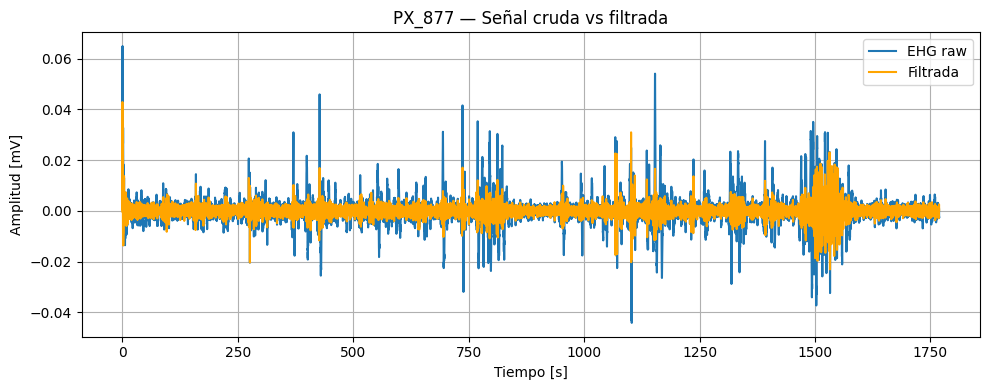

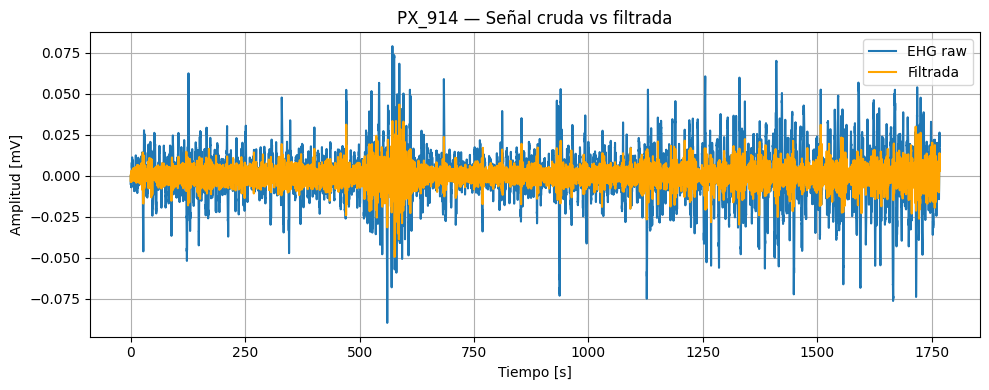

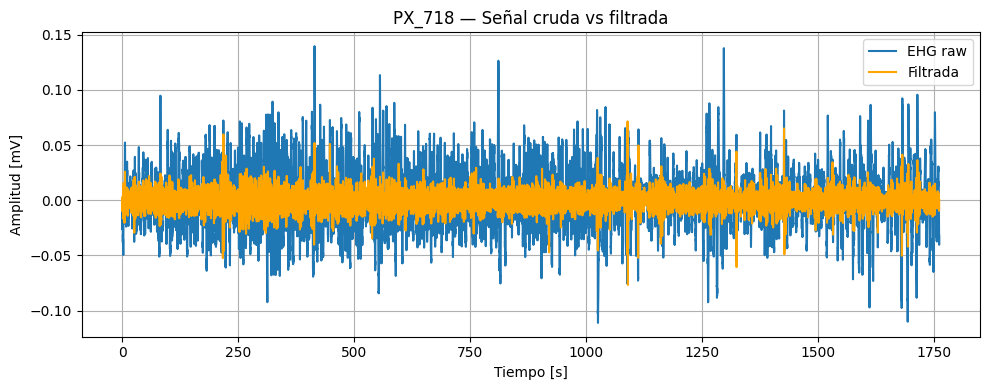

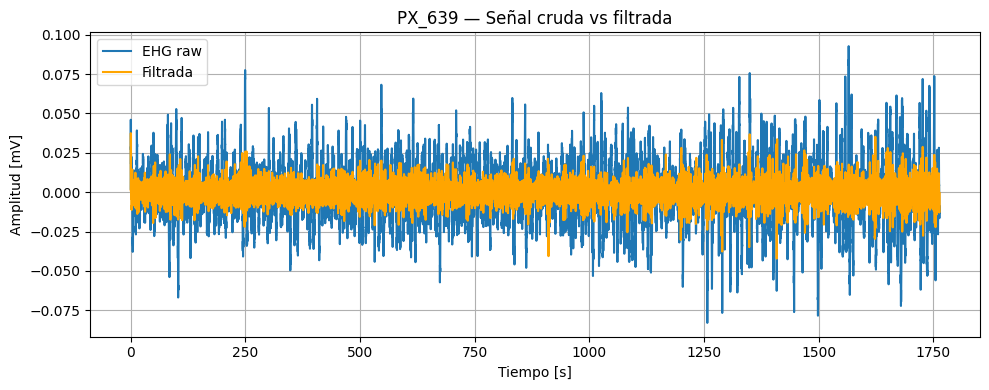

In [108]:
def analizar_paciente(path):
    
    # carga
    ehg, t, fs = cargar_senal(path)
    
    # PSD
    f_psd, psd, psd_db = calcular_psd(ehg, fs)
    
    # filtrado
    mi_sos_butter, ehg_filt, w, h, fase, retardo = filtrar_senal(ehg, fs)
    
    # normalización
    ehg_norm = normalizar_senal(ehg_filt)
    
    # segmentación
    ventanas, t_vent = segmentar_senal(ehg_norm, fs)
    
    # energía y rms
    energia, rms = calcular_energia_rms(ventanas)
    
    # features
    frec_mediana, sampen = calcular_features(ventanas, fs)
    
    return {
        "ehg": ehg,
        "f_psd": f_psd,
        "psd": psd,        
        "psd_db": psd_db,
        "ehg_filt": ehg_filt,
        "t": t,
        "fs": fs,
        "w": w,
        "h": h,
        "energia": energia,
        "rms": rms,
        "t_vent": t_vent,
        "frec_mediana": frec_mediana,
        "sampen": sampen,
        "mean_frec": np.nanmean(frec_mediana),
        "mean_sampen": np.nanmean(sampen)
    }

px_877 = analizar_paciente('data/tpehgdb/tpehg877')
px_914 = analizar_paciente('data/tpehgdb/tpehg914')
px_718 = analizar_paciente('data/tpehgdb/tpehg718')
px_639 = analizar_paciente('data/tpehgdb/tpehg639')

pacientes = [
    {'data': px_877,  'nombre': 'PX_877',  'grupo': 'pretermino'},
    {'data': px_914, 'nombre': 'PX_914', 'grupo': 'pretermino'},
    {'data': px_718,  'nombre': 'PX_718',  'grupo': 'termino'},
    {'data': px_639,  'nombre': 'PX_639',  'grupo': 'termino'},
]

# ---- SEÑAL RAW VS FILTRADA POR PACIENTE ----

for px in pacientes:
    plot_senal_filtrada(t=px['data']['t'], ehg=px['data']['ehg'], ehg_filt=px['data']['ehg_filt'], nombre=px['nombre'])


### RMS

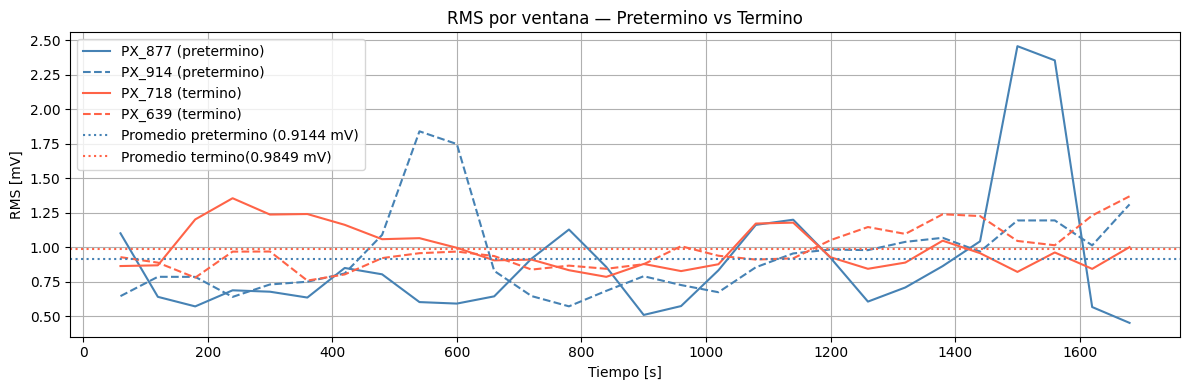

In [109]:
colores  = {'pretermino': 'steelblue', 'termino': 'tomato'}
conteo   = {'pretermino': 0, 'termino': 0}
rms_pre, rms_ter = [], []

plt.figure(figsize=(12, 4))
for px in pacientes:
    grupo = px['grupo']
    conteo[grupo] += 1
    ls = '-' if conteo[grupo] == 1 else '--'
    plt.plot(px['data']['t_vent'], px['data']['rms'],
             color=colores[grupo], linestyle=ls,
             label=f"{px['nombre']} ({grupo})")
    if grupo == 'pretermino':
        rms_pre.append(px['data']['rms'])
    else:
        rms_ter.append(px['data']['rms'])

prom_pre = np.mean(np.concatenate(rms_pre))
prom_ter = np.mean(np.concatenate(rms_ter))
plt.axhline(prom_pre, color=colores['pretermino'],  linestyle=':', linewidth=1.5,
            label=f'Promedio pretermino ({prom_pre:.4f} mV)')
plt.axhline(prom_ter, color=colores['termino'], linestyle=':', linewidth=1.5,
            label=f'Promedio termino({prom_ter:.4f} mV)')
plt.xlabel('Tiempo [s]')
plt.ylabel('RMS [mV]')
plt.title('RMS por ventana — Pretermino vs Termino')
plt.legend()
plt.grid(True)
plt.tight_layout()

El análisis del RMS por ventana no mostró diferencias marcadas entre los grupos pretérmino y término, con promedios de $0.914 mV$ y $0.985 mV$ respectivamente. Las curvas de ambos grupos se superponen a lo largo del registro, con alta variabilidad intragrupo. Cabe destacar que *PX_877* presenta un pico pronunciado hacia el final del registro que eleva su promedio, posiblemente asociado a un episodio de mayor actividad contráctil.
Este resultado es consistente con lo reportado en la literatura, donde el RMS como medida de amplitud global muestra mayor utilidad para diferenciar segmentos de contracción de segmentos de reposo dentro de un mismo registro, más que para discriminar entre grupos pretérmino y término [3].

### Frecuencia mediana

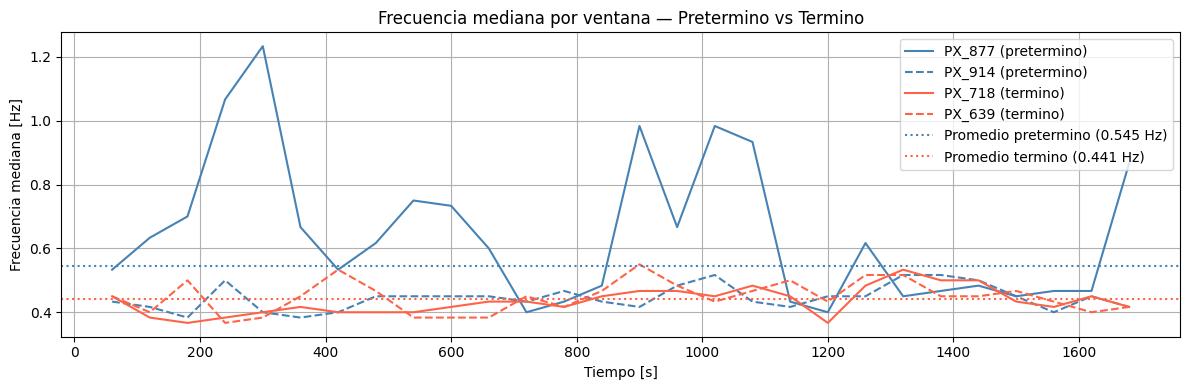

In [110]:
conteo = {'pretermino': 0, 'termino': 0}
frec_pre, frec_ter = [], []

plt.figure(figsize=(12, 4))
for px in pacientes:
    grupo = px['grupo']
    conteo[grupo] += 1
    ls = '-' if conteo[grupo] == 1 else '--'
    fm = px['data']['frec_mediana']
    plt.plot(px['data']['t_vent'][:len(fm)], fm,
             color=colores[grupo], linestyle=ls,
             label=f"{px['nombre']} ({grupo})")
    if grupo == 'pretermino':
        frec_pre.append(fm)
    else:
        frec_ter.append(fm)

prom_pre = np.nanmean(np.concatenate(frec_pre))
prom_ter = np.nanmean(np.concatenate(frec_ter))
plt.axhline(prom_pre, color=colores['pretermino'],  linestyle=':', linewidth=1.5,
            label=f'Promedio pretermino ({prom_pre:.3f} Hz)')
plt.axhline(prom_ter, color=colores['termino'], linestyle=':', linewidth=1.5,
            label=f'Promedio termino ({prom_ter:.3f} Hz)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Frecuencia mediana [Hz]')
plt.title('Frecuencia mediana por ventana — Pretermino vs Termino')
plt.legend()
plt.grid(True)
plt.tight_layout()

El análisis de la frecuencia mediana mostró la diferencia más clara entre grupos. El grupo pretérmino presentó un promedio de $0.545 Hz$ frente a $0.441 Hz$ del grupo término, con *PX_877* mostrando picos recurrentes por encima de $0.8 Hz$ a lo largo de todo el registro. *PX_914* mostró valores más cercanos al grupo término aunque su promedio sigue siendo superior.
Este resultado es consistente con la literatura, que reporta que los registros pretérmino tienden a presentar un desplazamiento del contenido espectral hacia frecuencias más altas respecto a los registros término, asociado a mayor excitabilidad del miometrio [3]. 

### Sample entropy

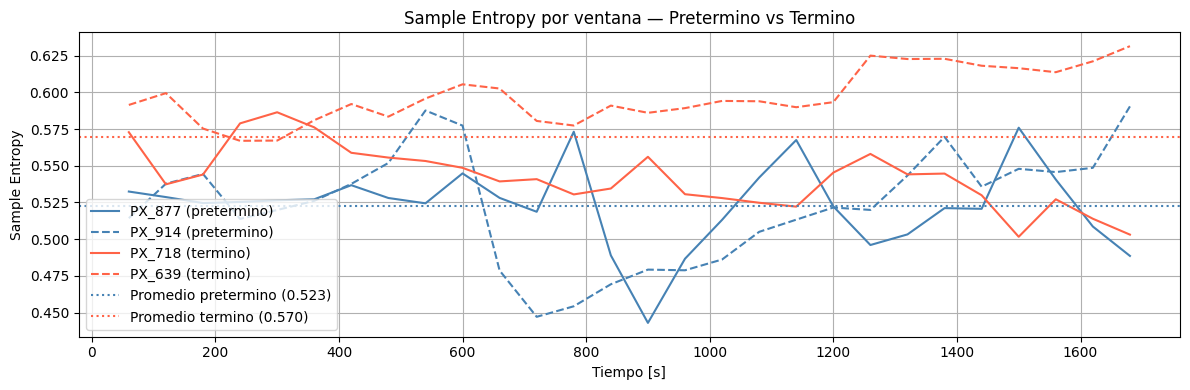

In [113]:
conteo = {'pretermino': 0, 'termino': 0}
se_pre, se_ter = [], []

plt.figure(figsize=(12, 4))
for px in pacientes:
    grupo = px['grupo']
    conteo[grupo] += 1
    ls = '-' if conteo[grupo] == 1 else '--'
    se = px['data']['sampen']
    plt.plot(px['data']['t_vent'][:len(se)], se,
             color=colores[grupo], linestyle=ls,
             label=f"{px['nombre']} ({grupo})")
    if grupo == 'pretermino':
        se_pre.append(se)
    else:
        se_ter.append(se)

prom_pre = np.nanmean(np.concatenate(se_pre))
prom_ter = np.nanmean(np.concatenate(se_ter))
plt.axhline(prom_pre, color=colores['pretermino'],  linestyle=':', linewidth=1.5,
            label=f'Promedio pretermino ({prom_pre:.3f})')
plt.axhline(prom_ter, color=colores['termino'], linestyle=':', linewidth=1.5,
            label=f'Promedio termino ({prom_ter:.3f})')
plt.xlabel('Tiempo [s]')
plt.ylabel('Sample Entropy')
plt.title('Sample Entropy por ventana — Pretermino vs Termino')
plt.legend()
plt.grid(True)
plt.tight_layout()

La Sample Entropy mostró promedios prácticamente idénticos entre grupos, con $0.523$ para pretérmino y $0.570$ para término. La diferencia es tan pequeña que no permite establecer ninguna tendencia entre grupos. Sin embargo, el análisis por paciente revela un comportamiento heterogéneo: *PX_877* presenta valores consistentemente más altos que el resto del registro durante gran parte del tiempo, mientras que *PX_914* se mantiene dentro del rango del grupo término. Esta alta variabilidad intragrupo es característica de medidas de entropía en señales EHG anteparto y ha sido documentada en la literatura [3].

El resultado sugiere que la Sample Entropy calculada sobre la señal completa sin segmentación por contracción tiene limitada capacidad discriminativa entre grupos pretérmino y término en registros anteparto con el tamaño muestral analizado. Su utilidad podría mejorarse calculándola específicamente sobre segmentos de contracción identificados, o combinándola con otras features en un esquema de clasificación multivariado.

## Conclusión

En este trabajo se implementó un procesamiento de señales de electrohisterografía (EHG) completo, aplicado a registros de pacientes con distintos desenlaces de parto con el objetivo de explorar diferencias en la actividad eléctrica uterina entre grupos pretérmino y término.

El preprocesamiento demostró ser una etapa fundamental para el análisis. El filtro pasabanda Butterworth diseñado a partir del análisis espectral previo permitió aislar eficazmente las componentes fisiológicas de interés $(0.3–2.5 Hz)$, eliminando la deriva de línea de base y el ruido de alta frecuencia presentes en los registros crudos. La implementación bidireccional garantizó fase nula, preservando la morfología temporal de la señal.

De las tres features analizadas, la frecuencia mediana fue la que mostró las diferencias más consistentes entre grupos, con un promedio de $0.545 Hz$ para pretérmino frente a $0.441 Hz$ para término. Este resultado es coherente con lo reportado en la literatura, donde el desplazamiento espectral hacia frecuencias más altas se asocia a mayor excitabilidad miometrial en embarazos con riesgo de parto prematuro [3]. El RMS no mostró diferencias relevantes entre grupos, con promedios de $0.914 mV$ y $0.985 mV$ respectivamente, lo cual es consistente con su limitada capacidad discriminativa en registros anteparto. La Sample Entropy presentó valores prácticamente idénticos entre grupos ($0.571$ vs $0.576$), con alta variabilidad intragrupo que impide extraer conclusiones sobre su capacidad discriminativa con el tamaño muestral analizado.

El trabajo tiene limitaciones importantes que deben considerarse al interpretar los resultados. El análisis se realizó sobre cuatro pacientes ($n=2$ por grupo), lo que no permite generalización estadística de los hallazgos. La alta variabilidad interindividual observada en todas las features, especialmente en SampEn, es característica de señales EHG anteparto y requiere muestras más grandes para detectar diferencias significativas entre grupos. 

Como líneas de trabajo futuro se identifican: la extensión del análisis a un mayor número de pacientes para validación estadística, la incorporación de técnicas de detección de contracciones para análisis por segmento, y la exploración de features adicionales como la frecuencia pico u otras métricas de entropía, que han mostrado resultados prometedores en la clasificación de tipos de parto [5].

## Bibliografía

[1] Fele-Žorž, G., Kavšek, G., Novak-Antolič, Ž., & Jager, F. (2008). 
A comparison of various linear and non-linear signal processing 
techniques to separate uterine EMG records of term and pre-term 
delivery groups. Medical & Biological Engineering & Computing, 
46(9), 911–922. https://doi.org/10.1007/s11517-008-0350-y
Fele-Žorž, G., Kavšek, G., Novak-Antolič, Ž., & Jager, F. (2012). 
Term-Preterm EHG Database (TPEHG DB). PhysioNet. 
https://doi.org/10.13026/C2FW2V

[2] Jager, F. (2023). An open dataset with electrohysterogram records of 
pregnancies ending in induced and cesarean section delivery. 
Scientific Data, 10(1), 669. https://doi.org/10.1038/s41597-023-02581-6

[3] Richman, J. S., & Moorman, J. R. (2000). Physiological time-series 
analysis using approximate entropy and sample entropy. 
American Journal of Physiology - Heart and Circulatory Physiology, 
278(6), H2039–H2049. https://doi.org/10.1152/ajpheart.2000.278.6.H2039

[4] J. Mas-Cabo, Y. Ye-Lin, J. Garcia-Casado, A. Díaz-Martinez, A. Perales-Marin, R. Monfort-Ortiz, A. Roca-Prats, Á. López-Corral y G. Prats-Boluda, "Robust Characterization of the Uterine Myoelectrical Activity in Different Obstetric Scenarios," Entropy, vol. 22, no. 7, p. 743, 2020. https://www.mdpi.com/1099-4300/22/7/743

[5] Goldberger, A. L., Amaral, L. A. N., Glass, L., Hausdorff, J. M., 
Ivanov, P. C., Mark, R. G., ... & Stanley, H. E. (2000). PhysioBank, 
PhysioToolkit, and PhysioNet: Components of a new research resource 
for complex physiologic signals. Circulation, 101(23), e215–e220. 
https://doi.org/10.1161/01.CIR.101.23.e215

[6] Holton, T. (2021). Digital Signal Processing: Principles and Applications. Cambridge: Cambridge University Press. 